In [9]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

import numpy as np

import itertools

D = 2

N = 256
L = 5.*np.pi

N_f = 4*N
L_f = 4*L

grid_dims = [N for _ in range(D)]
grid_dims_f = [N_f for _ in range(D)]

phys_dims = [L for _ in range(D)]
phys_dims_f = [L_f for _ in range(D)]

twopi = 2.*np.pi

dk_f = twopi/L_f
dk = twopi/L

dx_f = L_f/N_f
dx = L/N

BREAK = 25 * dk_f

In [10]:
f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims_f, (-2., -4.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': 0.1})
idx = tuple([slice(N_f//2-N//2, N_f//2+N//2) for _ in range(D)])
f = f_f[idx]
f = f - np.mean(f)

from scipy.signal import windows
f_p = f * statistics_base.ndim_func(windows.tukey, (N, N), (N, 0.1))

#f_p = np.pad(f, (int(1.5*N), int(1.5*N)))

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:105: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)


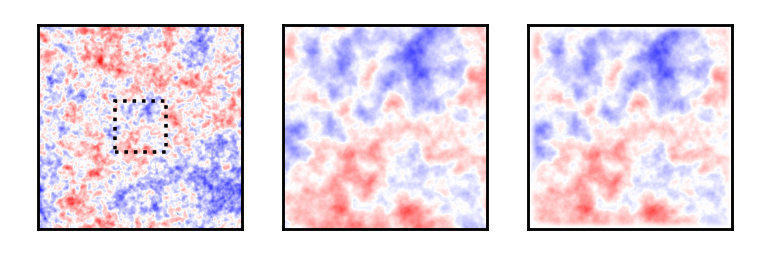

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(3.5, 10.5), dpi=256)
cmin, cmax = plotting.get_minmax(f_f)
ax[0].imshow(f_f, origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
ax[1].imshow(f, origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
ax[2].imshow(f_p, origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
for axx in ax:
    axx.set_xticks([])
    axx.set_yticks([])
rect = patches.Rectangle((N_f//2-N//2, N_f//2-N//2), N, N, linewidth=1., edgecolor='black', linestyle=':', facecolor='none')
ax[0].add_patch(rect)

/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 0, 'Wavenumber, $k L / 2 \\pi$')

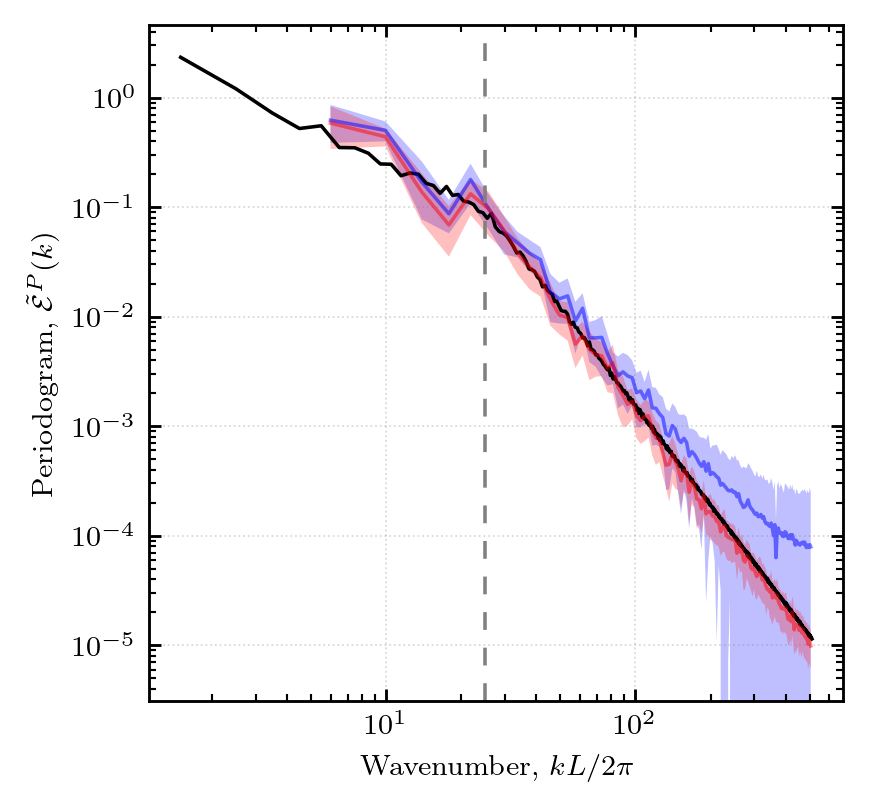

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)


kD_f, fekD_f = per_spectra.modal_spectrum(f_f, phys_dims=phys_dims_f)
fekD_f = fekD_f * (dk_f/twopi)**D
ko_f, feko_f, w_f = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='omni', lenn=phys_dims_f)
_, feke_f, _ = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='error', lenn=phys_dims_f)
feke_f = np.sqrt((2.*np.pi*ko_f*feke_f)**2)

ko_f = ko_f * L_f / twopi

ax.fill_between(ko_f, feko_f-feke_f, feko_f+feke_f, color='black', alpha=0.25, edgecolor='none')
ax.loglog(ko_f, feko_f, color='black', linewidth=1.)


kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
_, feke, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='error', lenn=phys_dims)
feke = np.sqrt((2.*np.pi*ko*feke)**2)

ko = ko * L_f / twopi

ax.fill_between(ko, feko-feke, feko+feke, color='blue', alpha=0.25, edgecolor='none')
ax.loglog(ko, feko, color='blue', linewidth=1., alpha=0.5)


kD_p, fekD_p = per_spectra.modal_spectrum(f_p, phys_dims=phys_dims)
fekD_p = fekD_p * (dk/twopi)**D
ko_p, feko_p, w_p = spectra_base.spectrum_integrate(kD_p, fekD_p, spec_type='omni', lenn=phys_dims)
_, feke_p, _ = spectra_base.spectrum_integrate(kD_p, fekD_p, spec_type='error', lenn=phys_dims)
feke_p = np.sqrt((2.*np.pi*ko_p*feke_p)**2)

ko_p = ko_p * L_f / twopi

ax.fill_between(ko_p, feko_p-feke_p, feko_p+feke_p, color='red', alpha=0.25, edgecolor='none')
ax.loglog(ko_p, feko_p, color='red', linewidth=1., alpha=0.5)


ax.axvline(BREAK * L_f / twopi, linewidth=1., color='gray', linestyle=(0,(5,5)))

#ax.set_ylim((1e-10, 1e0))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k L / 2 \pi$')

Text(0.5, 0, '$\\lambda$')

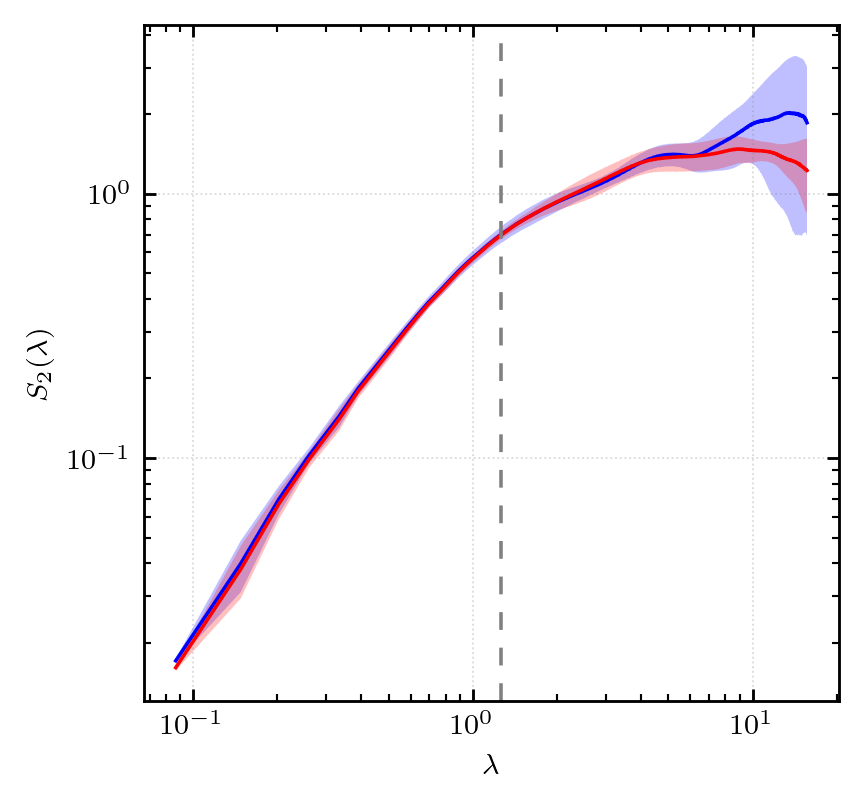

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

# lv_f = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims_f])
# sf_f = strfn.process_lags(f_f, f_f, lv_f, lenn=phys_dims_f, shape=[2*n+1 for n in grid_dims_f], orders=[2], periodic=True)[0]
# l_f, sf2_f, w_f = statistics_base.bin_data(lv_f, sf_f, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx)
# lvm_f = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims_f]) * dx
# ax.loglog(lvm_f, sf_f, linewidth=1., color='black')


lv = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf = strfn.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=False)[0]
lvm = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx

l, sf2, w = statistics_base.bin_data(lvm, sf, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, bin_loc='true_center')
_l, sf2err, _ = statistics_base.bin_data(lvm, sf, bin_func=np.nanstd, cut_excess=True, nan_small=False, min_bin=dx, bin_loc='true_center')

ax.fill_between(_l, sf2-sf2err, sf2+sf2err, color='blue', alpha=0.25, edgecolor='none')
ax.loglog(l, sf2, linewidth=1., color='blue')


lv_p = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf_p = strfn.process_lags(f_p, f_p, lv_p, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx

l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, bin_loc='true_center')
_l_p, sf2_perr, _ = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanstd, cut_excess=True, nan_small=False, min_bin=dx, bin_loc='true_center')

ax.fill_between(_l, sf2_p-sf2_perr, sf2_p+sf2_perr, color='red', alpha=0.25, edgecolor='none')
ax.loglog(l_p, sf2_p, linewidth=1., color='red')


ax.axvline(np.pi/BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$S_2(\lambda)$')
ax.set_xlabel(r'$\lambda$')

In [19]:

def omni_spectrum_2(ell, sf2, phys_dims, grid_dims):
    dS = np.gradient(sf2, dx)
    dell = np.gradient(ell, dx)
    fek = (ell)**2 * (dS) * (twopi**D / 4.) / (twopi)
    kk = 2.*np.pi / ell
    return kk[::-1], fek[::-1]

def omni_spectrum(ell, sf2, phys_dims, grid_dims):
    kk = 2.*np.pi / ell
    #kk = 1. / ell
    fek = (twopi**D / 4.) * sf2 * ell / (twopi)
    return kk[::-1], fek[::-1]


lk, s = omni_spectrum(l, sf2, phys_dims, grid_dims)

s = s * (dk/twopi)**D * 4
lk = lk * L_f / twopi


lk2, s2 = omni_spectrum_2(l, sf2, phys_dims, grid_dims)

s2 = s2 * (dk/twopi)**D * 4
lk2 = lk2 * L_f / twopi


lk2_p, s2_p = omni_spectrum_2(l_p, sf2_p, phys_dims, grid_dims)

s2_p = s2_p * (dk/twopi)**D * 4
lk2_p = lk2_p * L_f / twopi


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(5e-06, 10)

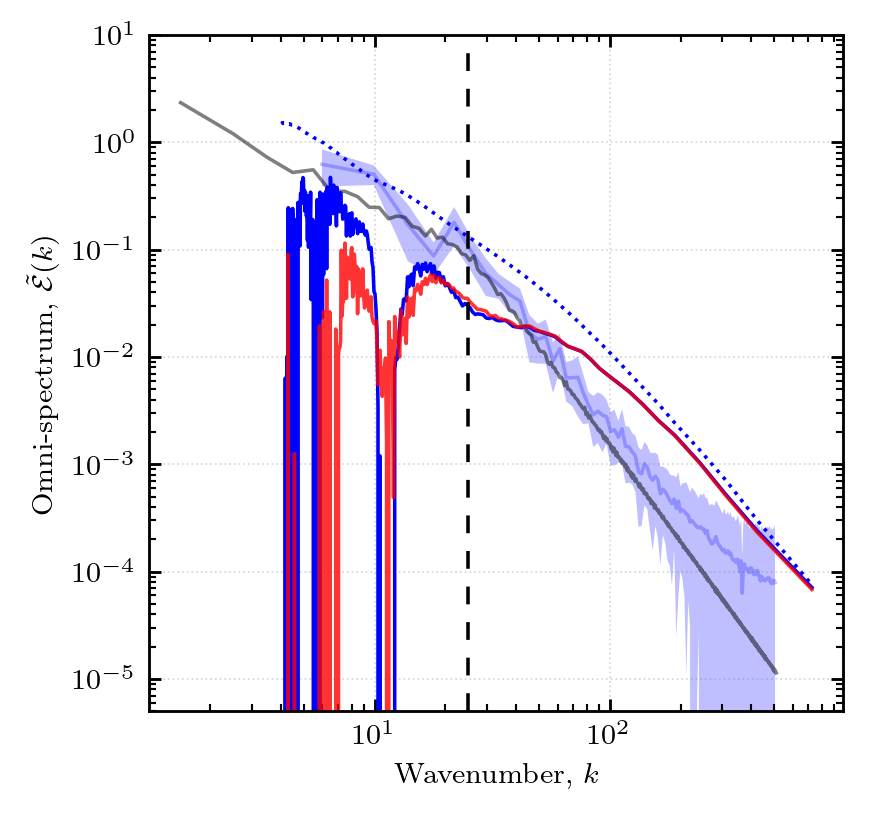

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.fill_between(ko, feko-feke, feko+feke, color='blue', alpha=0.25, edgecolor='none')
ax.loglog(ko, feko, color='blue', linewidth=1., alpha=0.25)

ax.loglog(ko_f, feko_f, color='black', linewidth=1., alpha=0.5)

ax.loglog(lk2, s2, linewidth=1., color='blue')
ax.loglog(lk, s*2., linewidth=1., color='blue', linestyle=':')

ax.loglog(lk2_p, s2_p, linewidth=1., color='red', alpha=0.8)

ax.axvline(BREAK * L_f / twopi, color='black', linestyle=(0,(5,5)), linewidth=1.)
ax.set_ylim((1e-10, 1e2))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=False, fancybox=False)

ax.set_ylabel(r'Omni-spectrum, $\tilde{\mathcal{E}}(k)$')
ax.set_xlabel(r'Wavenumber, $k$')

#ax.set_xlim((30, 300))
ax.set_ylim((5e-6,10))